# Pupil, locomotion and the population state of VISp: group analysis

Allen Visual Coding – Neuropixels (DANDI:000021)

Multi-subject extension of the single-session analysis in `Pupila_estado_VISp_individual_analysis.ipynb`. One session is anecdotal; with every session that has eye tracking the descriptive finding can be turned into a population-level statement.

The single-session pipeline, applied session by session:

1. Scan the dandiset by streaming to find the sessions with pupil tracking, and cache the list.
2. Wrap the single-session pipeline (streaming, QC, alignment with `pynapple`, PCA, cross-correlation with a circular null, partial control for running speed) in one function per session.
3. Sweep the sessions with incremental caching, and decode the state from pupil, running speed and pupil-minus-running.
4. Test at group level whether the pupil carries state information beyond locomotion.

## Background

In session `sub-738651046_ses-760693773` the pupil predicted the state of VISp almost entirely because both pupil and cortex follow locomotion: running dominated the state (|r| = 0.758) and, once regressed out, the pupil-state coupling collapsed from 0.285 to 0.071 (p = 0.79).

The question here is whether that holds across animals: does the pupil index the population state of VISp beyond locomotion, and does running dominate the state consistently?

Regime: the spontaneous block (grey screen, constant luminance), where reading pupil size as arousal is cleanest.

---
## 1. Environment

In [1]:
# Uncomment to install the dependencies:
# %pip install dandi remfile h5py pynwb pynapple scikit-learn scipy tqdm pandas matplotlib

In [2]:
import warnings; warnings.filterwarnings("ignore")
import os, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Streaming NWB / DANDI
import h5py, remfile, pynwb
from dandi.dandiapi import DandiAPIClient

# Time series, ML and statistics
import pynapple as nap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import Ridge
from scipy.stats import rankdata, wilcoxon, binomtest
from scipy.ndimage import gaussian_filter1d

# GRU decoder
import torch
import torch.nn as nn

# Progress bars
from tqdm.auto import tqdm

print("Environment loaded. Key versions:")
for n, m in [("numpy", np), ("pandas", pd), ("pynwb", pynwb), ("pynapple", nap)]:
    print(f"  {n:9s} {m.__version__}")

Environment loaded. Key versions:
  numpy     2.5.1
  pandas    3.0.3
  pynwb     4.0.0
  pynapple  0.11.4


### 1.1 Parameters

In [3]:
# --- Dataset ---
DANDISET_ID      = "000021"
DANDISET_VERSION = "draft"
REGION           = "VISp"

# --- Time grid and QC (same as the single-session notebook) ---
BIN          = 0.050
SMOOTH_SIGMA = 0.100
QC_QUALITY        = "good"
QC_ISI_MAX        = 0.5
QC_AMP_CUTOFF_MAX = 0.1
QC_PRESENCE_MIN   = 0.9

# --- Neural state and correlation ---
N_PCA        = 3
FRAC_TRAIN   = 0.70
LAG_MAX      = 3.0            # lag range: +/- LAG_MAX (s)
N_PERM       = 2000           # circular permutations per coupling
CORR_METHOD  = "spearman"
SEED         = 42

# --- Per-session inclusion criteria ---
MIN_SPONT_MIN = 4.0
MIN_UNITS     = 30
MIN_UNITS_PCA = 5             # absolute minimum to attempt PCA

# --- Decoding (Ridge GLM + GRU) ---
RUN_DECODING = True           # decode the state from pupil / running speed
RUN_GRU      = True           # False = GLM only, faster over many sessions
TAU_GRID     = np.round(np.arange(-2.0, 2.0 + 1e-9, 0.25), 3)   # decoder lag sweep (s)
DEC_SEQ      = 20             # bins of pupil seen by the GRU (20 x 50 ms = 1 s)
GRU_HIDDEN, GRU_EPOCHS, GRU_LR, GRU_BATCH = 32, 80, 5e-3, 256

# --- Group sweep control ---
MAX_SESSIONS = None              # None = every session; set an integer to process fewer
SCAN_CSV     = "sessions_with_pupil_000021.csv"
RESULTS_CSV  = "group_spontaneous_results.csv"

np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Region={REGION} | bin={BIN*1000:.0f}ms | LAG_MAX=+/-{LAG_MAX}s | N_PERM={N_PERM}")
print(f"MAX_SESSIONS={MAX_SESSIONS} (None = all) | decoding={RUN_DECODING} (GRU={RUN_GRU}) | device={DEVICE}")

Region=VISp | bin=50ms | LAG_MAX=+/-3.0s | N_PERM=2000
MAX_SESSIONS=None (None = all) | decoding=True (GRU=True) | device=cpu


---
## 2. Finding the sessions with pupil tracking

Not every session includes eye tracking. Each session file is checked for `processing/filtered_gaze_mapping/pupil_area`, reading only its HDF5 structure.

`h5py` over `remfile` reads the index of the remote file, so testing whether an object exists does not download its data. Walking several dozen files still takes a few minutes, so the list is cached in `sessions_with_pupil_000021.csv` and the scan runs once.

In [4]:
PUPIL_PATH = "processing/filtered_gaze_mapping/pupil_area"

def pupil_present(url):
    rem = remfile.File(url)
    with h5py.File(rem, "r") as f:
        return PUPIL_PATH in f

if os.path.exists(SCAN_CSV):
    df_sessions = pd.read_csv(SCAN_CSV)
    print(f"Cached list: {len(df_sessions)} sessions with pupil tracking (from {SCAN_CSV}).")
else:
    rows = []
    with DandiAPIClient() as client:
        dandiset = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
        # Session files only: per-probe LFP files carry "probe-" and have no eye-tracking
        session_assets = [a for a in dandiset.get_assets()
                          if a.path.endswith(".nwb") and "probe-" not in a.path]
        print(f"Checking {len(session_assets)} session files...")
        for a in tqdm(session_assets, desc="scanning for pupil"):
            url = a.get_content_url(follow_redirects=1, strip_query=True)
            try:
                if pupil_present(url):
                    m_sub = re.search(r"sub-([^_/]+)", a.path)
                    m_ses = re.search(r"ses-([^_/]+)", a.path)
                    rows.append({"subject": m_sub.group(1) if m_sub else None,
                                 "session": m_ses.group(1) if m_ses else None,
                                 "path": a.path, "asset_id": a.identifier, "url": url})
            except Exception as e:
                print(f"  ! error in {a.path}: {e}")
    df_sessions = pd.DataFrame(rows)
    df_sessions.to_csv(SCAN_CSV, index=False)
    print(f"{len(df_sessions)} sessions with pupil tracking. Saved to {SCAN_CSV}.")

display(df_sessions.head(10))

Cached list: 26 sessions with pupil tracking (from sessions_with_pupil_000021.csv).


,subject,session,path,asset_id,url
0,719817799,744228101.nwb,sub-719817799/sub-719817799_ses-744228101.nwb,eb36f94f-d6e7-45c6-aa02-7d4ed23453d3,https://dandiarchive.s3.amazonaws.com/blobs/11...
1,719828686,754312389.nwb,sub-719828686/sub-719828686_ses-754312389.nwb,5a58bf3d-a1b9-444b-8ab0-ef5478aa42a6,https://dandiarchive.s3.amazonaws.com/blobs/e1...
2,722882751,743475441.nwb,sub-722882751/sub-722882751_ses-743475441.nwb,522e8054-34ca-4579-ae80-350d0b24e0f4,https://dandiarchive.s3.amazonaws.com/blobs/c5...
3,723627600,742951821.nwb,sub-723627600/sub-723627600_ses-742951821.nwb,96c200cf-29c2-457a-b2f3-99f11de5b039,https://dandiarchive.s3.amazonaws.com/blobs/89...
4,726141242,750332458.nwb,sub-726141242/sub-726141242_ses-750332458.nwb,286c7b06-3cde-4261-9090-e6fbe6c81945,https://dandiarchive.s3.amazonaws.com/blobs/74...
5,726162193,750749662.nwb,sub-726162193/sub-726162193_ses-750749662.nwb,3876c5f1-f38a-4c89-8f54-6128538f0066,https://dandiarchive.s3.amazonaws.com/blobs/fe...
6,726170927,746083955.nwb,sub-726170927/sub-726170927_ses-746083955.nwb,2e6df882-f31a-440b-a572-ba717a95bf80,https://dandiarchive.s3.amazonaws.com/blobs/e3...
7,726298249,754829445.nwb,sub-726298249/sub-726298249_ses-754829445.nwb,488a9bea-96fb-4028-a33a-08650f50be63,https://dandiarchive.s3.amazonaws.com/blobs/10...
8,730756767,757970808.nwb,sub-730756767/sub-730756767_ses-757970808.nwb,dfc3db15-066a-4a07-b615-a4d7e85c44e1,https://dandiarchive.s3.amazonaws.com/blobs/7c...
9,730760263,755434585.nwb,sub-730760263/sub-730760263_ses-755434585.nwb,edf10182-5a4c-454f-ad23-47987a5ca256,https://dandiarchive.s3.amazonaws.com/blobs/13...


---
## 3. The single-session pipeline as a function

`analizar_sesion` returns a dictionary of metrics, one row per session, reusing the logic validated on the single session: streaming, VISp QC, alignment with `pynapple`, train-only PCA, cross-correlation with a circular null, and the partial control for running speed.

### 3.1 Cross-correlation, null and running-speed helpers

In [5]:
# --- Circular cross-correlation (FFT) with circular-shift null ---
Lb        = int(round(LAG_MAX / BIN))
lags_bins = np.arange(-Lb, Lb + 1)
lags_s    = lags_bins * BIN

def _preparar(v):
    v = rankdata(v) if CORR_METHOD == "spearman" else np.asarray(v, float).copy()
    v = v - v.mean()
    return v / (np.linalg.norm(v) + 1e-12)

def analizar_acople(neural, pupil1d, n_perm=N_PERM):
    # Statistic = max |correlation| within +/-LAG_MAX; p from circular shifts, which preserve autocorrelation.
    a = _preparar(neural); b = _preparar(pupil1d); N = len(a)
    C = np.fft.irfft(np.conj(np.fft.rfft(a)) * np.fft.rfft(b), n=N)   # C[m] = corr(a[t], b[t+m])
    curva = C[(0 + lags_bins) % N]
    i = int(np.argmax(np.abs(curva))); stat = float(abs(curva[i]))
    rloc = np.random.default_rng(SEED)
    offs = rloc.integers(1, N, size=n_perm)
    stat_null = np.array([np.abs(C[(s + lags_bins) % N]).max() for s in offs])
    p = (1 + int(np.sum(stat_null >= stat))) / (n_perm + 1)
    return {"lag": float(lags_s[i]), "r_signed": float(curva[i]), "absr": stat, "p": p}

def quitar_carrera(sig, run):
    # Residual of 'sig' after regressing it on 'run': removes linear contemporaneous locomotion.
    A = np.column_stack([run, np.ones_like(run)])
    beta, *_ = np.linalg.lstsq(A, sig, rcond=None)
    return sig - A @ beta

def _interp_nan(v):
    if v is None or not np.isnan(v).any():
        return v
    idx = np.arange(len(v)); ok = ~np.isnan(v)
    v[~ok] = np.interp(idx[~ok], idx[ok], v[ok]); return v

# --- Load the running-speed signal, whose path varies across sessions ---
def cargar_carrera(nwb):
    cand = []
    for mod_name, mod in nwb.processing.items():
        for name in mod.data_interfaces.keys():
            if any(k in name.lower() for k in ("run", "speed", "velocity")):
                cand.append(("processing", mod_name, name))
    for name in nwb.acquisition.keys():
        if any(k in name.lower() for k in ("run", "speed", "velocity")):
            cand.append(("acquisition", None, name))
    # prefer a name containing "speed" when there are several candidates
    cand.sort(key=lambda c: (0 if "speed" in c[-1].lower() else 1))
    for origen, mod_name, name in cand:
        try:
            obj = nwb.processing[mod_name][name] if origen == "processing" else nwb.acquisition[name]
            d = np.abs(np.asarray(obj.data[:], dtype=float))
            if getattr(obj, "timestamps", None) is not None:
                t = np.asarray(obj.timestamps[:], dtype=float)
            else:
                t0 = float(getattr(obj, "starting_time", 0.0) or 0.0)
                t = t0 + np.arange(len(d)) / float(obj.rate)
            if len(t) == len(d) and len(d) > 10:
                d = _interp_nan(d)
                return nap.Tsd(t=t, d=d), f"{origen}:{mod_name or ''}/{name}"
        except Exception:
            continue
    return None, None

print("Helpers ready.")

Helpers ready.


### 3.2 Decoding helpers (GLM and GRU)

Instead of correlating, a model reconstructs the state from a signal, the delay tau is swept and the prediction-target correlation is measured on the test split, the metric being robust to drift. Ridge GLM as the linear baseline, GRU as the non-linear alternative. Each session is decoded from the pupil, from running speed, and from the pupil with running speed regressed out, which is the predictive analogue of the partial correlation.

In [6]:
def _indices_tau(n, P, tau, cut):
    tr, te = [], []
    for i in range(n):
        j0, j1 = i - tau - P + 1, i - tau
        if j0 < 0 or j1 < 0 or j1 >= n: continue
        if i < cut:      tr.append(i)
        elif j0 >= cut:  te.append(i)
    return np.array(tr, int), np.array(te, int)

def _plano_tau(Xf, Yt, tau, P, cut):
    tr, te = _indices_tau(len(Yt), P, tau, cut)
    f = lambda idx: np.stack([Xf[i-tau-P+1:i-tau+1].reshape(-1) for i in idx])
    return f(tr), Yt[tr], f(te), Yt[te]

def _seq_tau(Xf, Yt, tau, P, cut):
    tr, te = _indices_tau(len(Yt), P, tau, cut)
    s = lambda idx: np.stack([Xf[i-tau-P+1:i-tau+1] for i in idx])
    return s(tr), Yt[tr], s(te), Yt[te]

def _r_pred(yt, yp):
    rs = []
    for j in range(yt.shape[1]):
        rs.append(0.0 if (yp[:, j].std() < 1e-9 or yt[:, j].std() < 1e-9)
                  else np.corrcoef(yt[:, j], yp[:, j])[0, 1])
    return float(np.nanmean(rs))

def _glm_multi(Xtr, Ytr, Xte):
    return np.stack([Ridge(alpha=1.0).fit(Xtr, Ytr[:, j]).predict(Xte)
                     for j in range(Ytr.shape[1])], axis=1)

class _GRU(nn.Module):
    def __init__(self, n_in, n_h, n_out):
        super().__init__()
        self.gru = nn.GRU(n_in, n_h, batch_first=True); self.fc = nn.Linear(n_h, n_out)
    def forward(self, x):
        o, _ = self.gru(x); return self.fc(o[:, -1, :])

def _entrenar_gru(Xtr, Ytr, Xte, n_in, n_out):
    torch.manual_seed(SEED)
    m = _GRU(n_in, GRU_HIDDEN, n_out).to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=GRU_LR); lossf = nn.MSELoss()
    Xt = torch.tensor(Xtr, dtype=torch.float32, device=DEVICE)
    Yt = torch.tensor(Ytr, dtype=torch.float32, device=DEVICE); N = Xt.shape[0]
    m.train()
    for _ in range(GRU_EPOCHS):
        perm = torch.randperm(N, device=DEVICE)
        for k in range(0, N, GRU_BATCH):
            idx = perm[k:k+GRU_BATCH]; opt.zero_grad()
            loss = lossf(m(Xt[idx]), Yt[idx]); loss.backward(); opt.step()
    m.eval()
    with torch.no_grad():
        return m(torch.tensor(Xte, dtype=torch.float32, device=DEVICE)).cpu().numpy()

def _feat(sig, cut):
    # Features of a 1D signal: smoothed plus derivative, standardised on train only.
    sm = gaussian_filter1d(sig, SMOOTH_SIGMA / BIN); dv = np.gradient(sm) / BIN
    M = np.column_stack([sm, dv])
    return StandardScaler().fit(M[:cut]).transform(M)

def decode_state_from(feats, Yz, cut, con_gru=False):
    # Maximum prediction-target r over TAU_GRID -> (r_glm, tau_glm, r_gru, tau_gru).
    best_g = (-np.inf, np.nan); best_r = (-np.inf, np.nan)
    for tau_s in TAU_GRID:
        tau = int(round(tau_s / BIN))
        Xtr, Ytr, Xte, Yte = _plano_tau(feats, Yz, tau, 1, cut)
        if len(Yte) > 5:
            r = _r_pred(Yte, _glm_multi(Xtr, Ytr, Xte))
            if r > best_g[0]: best_g = (r, tau_s)
        if con_gru and RUN_GRU:
            Xs, Ys, Xes, Yes = _seq_tau(feats, Yz, tau, DEC_SEQ, cut)
            if len(Yes) > 5:
                rg = _r_pred(Yes, _entrenar_gru(Xs, Ys, Xes, feats.shape[1], Yz.shape[1]))
                if rg > best_r[0]: best_r = (rg, tau_s)
    return best_g[0], best_g[1], best_r[0], best_r[1]

print("Decoding helpers ready. DEVICE =", DEVICE)

Decoding helpers ready. DEVICE = cpu


### 3.3 `analizar_sesion`

In [7]:
def _resolver_url(row):
    # Re-resolve the S3 URL from the asset_id, in case the cached one expired.
    try:
        with DandiAPIClient() as client:
            ds = client.get_dandiset(DANDISET_ID, DANDISET_VERSION)
            return ds.get_asset(row["asset_id"]).get_content_url(follow_redirects=1, strip_query=True)
    except Exception:
        return row["url"]

def analizar_sesion(row):
    # Metrics of the spontaneous block for one session; "status" reports why a session was skipped.
    base = {"subject": row["subject"], "session": row["session"], "path": row["path"]}
    try:
        rem = remfile.File(row["url"]); h5 = h5py.File(rem, "r")
    except Exception:
        row = row.copy(); row["url"] = _resolver_url(row)
        rem = remfile.File(row["url"]); h5 = h5py.File(rem, "r")
    io = pynwb.NWBHDF5IO(file=h5, load_namespaces=True); nwb = io.read()
    try:
        if "spontaneous_presentations" not in nwb.intervals:
            return {**base, "status": "sin_espontaneo"}
        spont = nwb.intervals["spontaneous_presentations"].to_dataframe()
        dur_min = float((spont["stop_time"] - spont["start_time"]).sum()) / 60.0

        cols = [c for c in ["peak_channel_id","quality","isi_violations","amplitude_cutoff",
                            "presence_ratio","firing_rate"] if c in nwb.units.colnames]
        um = pd.DataFrame({c: nwb.units[c].data[:] for c in cols}, index=nwb.units.id[:])
        elec = nwb.electrodes.to_dataframe()
        um["location"] = um["peak_channel_id"].map(elec["location"])
        if "quality" in um: um["quality"] = um["quality"].astype(str)
        mask = um["location"] == REGION
        if "quality" in um:          mask &= um["quality"] == QC_QUALITY
        if "isi_violations" in um:   mask &= um["isi_violations"] <= QC_ISI_MAX
        if "amplitude_cutoff" in um: mask &= um["amplitude_cutoff"] <= QC_AMP_CUTOFF_MAX
        if "presence_ratio" in um:   mask &= um["presence_ratio"] >= QC_PRESENCE_MIN
        n_units = int(mask.sum())
        plan_a = (dur_min >= MIN_SPONT_MIN) and (n_units >= MIN_UNITS)
        if n_units < MIN_UNITS_PCA:
            return {**base, "status": "pocas_unidades", "dur_min": dur_min, "n_units": n_units}

        sel = um[mask]; pos = np.where(mask.values)[0]
        ep = nap.IntervalSet(start=spont["start_time"].values, end=spont["stop_time"].values)
        spikes = {}
        for uid, p in zip(sel.index, pos):
            st = np.asarray(nwb.units["spike_times"][p])
            st = st[(st >= float(ep.start[0])) & (st <= float(ep.end[-1]))]
            spikes[int(uid)] = nap.Ts(t=st)
        tsg = nap.TsGroup(spikes)

        po = nwb.processing["filtered_gaze_mapping"]["pupil_area"]
        pv = np.asarray(po.data[:], float); pt = np.asarray(po.timestamps[:], float)
        nanm = np.isnan(pv)
        pv[nanm] = np.interp(pt[nanm], pt[~nanm], pv[~nanm])
        pupila = nap.Tsd(t=pt, d=pv)
        carrera, run_src = cargar_carrera(nwb)

        tasas = (tsg.count(BIN, ep=ep) / BIN).smooth(SMOOTH_SIGMA)
        pup_b = pupila.bin_average(BIN, ep=ep)
        L = min(len(np.asarray(tasas.t)), len(np.asarray(pup_b.t)))
        RATES = np.asarray(tasas.values)[:L]
        PUP   = _interp_nan(np.asarray(pup_b.values)[:L].astype(float))
        RUN = None
        if carrera is not None:
            run_b = carrera.bin_average(BIN, ep=ep)
            L2 = min(L, len(np.asarray(run_b.t)))
            RUN = _interp_nan(np.asarray(run_b.values)[:L2].astype(float))
            RATES, PUP = RATES[:L2], PUP[:L2]; L = L2

        n_bins = L; cut = int(FRAC_TRAIN * n_bins)
        Rz = StandardScaler().fit(RATES[:cut]).transform(RATES)
        pca = PCA(n_components=min(N_PCA, RATES.shape[1])).fit(Rz[:cut])
        Y = pca.transform(Rz); pc1 = Y[:, 0].astype(float)

        out = {**base, "status": "ok", "plan_a": plan_a, "dur_min": dur_min, "n_units": n_units,
               "evr_pc1": float(pca.explained_variance_ratio_[0]), "run_src": run_src,
               "has_running": RUN is not None}
        # --- Cross-correlation with circular null (main analysis) ---
        ac = analizar_acople(pc1, PUP)
        out.update({"r_simple": ac["absr"], "lag_simple": ac["lag"], "p_simple": ac["p"]})
        if RUN is not None:
            acp = analizar_acople(quitar_carrera(pc1, RUN), quitar_carrera(PUP, RUN))
            acr = analizar_acople(pc1, RUN)
            acrp = analizar_acople(PUP, RUN)
            out.update({"r_partial": acp["absr"], "p_partial": acp["p"], "lag_partial": acp["lag"],
                        "r_run_pc1": acr["absr"], "p_run_pc1": acr["p"],
                        "r_run_pupil": acrp["absr"], "p_run_pupil": acrp["p"]})
        # --- Decoding (GLM / GRU) ---
        if RUN_DECODING:
            Yz = StandardScaler().fit(Y[:cut]).transform(Y)
            rg, tg, rgru, tgru = decode_state_from(_feat(PUP, cut), Yz, cut, con_gru=True)
            out.update({"dec_r_glm": rg, "dec_tau_glm": tg, "dec_r_gru": rgru, "dec_tau_gru": tgru})
            if RUN is not None:
                out["dec_r_run_glm"] = decode_state_from(_feat(RUN, cut), Yz, cut)[0]
                # Predictive analogue of the partial control: state and pupil residualised on running speed
                Yres = np.column_stack([quitar_carrera(Y[:, j], RUN) for j in range(Y.shape[1])])
                Yzr  = StandardScaler().fit(Yres[:cut]).transform(Yres)
                psm  = gaussian_filter1d(PUP, SMOOTH_SIGMA / BIN)
                Xpr  = np.column_stack([quitar_carrera(psm, RUN),
                                        quitar_carrera(np.gradient(psm) / BIN, RUN)])
                Xpr  = StandardScaler().fit(Xpr[:cut]).transform(Xpr)
                out["dec_r_glm_partial"] = decode_state_from(Xpr, Yzr, cut)[0]
        return out
    except Exception as e:
        return {**base, "status": f"error: {type(e).__name__}: {e}"}
    finally:
        io.close(); h5.close(); rem.close()

print("analizar_sesion ready.")

analizar_sesion ready.


---
## 4. Sweeping the sessions

`analizar_sesion` is applied to every session with pupil tracking, with incremental caching: sessions already present in `group_spontaneous_results.csv` are skipped, so the sweep can be stopped and resumed without repeating the streaming.

This is the slow part. Each session streams several GB, reading the `spike_times` of up to ~100 units and binning ~20 min of recording, and then runs the decoding: the GLM across tau and, with `RUN_GRU = True`, one GRU per tau. Expect a few minutes per session. `MAX_SESSIONS` limits how many are processed per run, and `RUN_GRU = False` falls back to the GLM alone, which is considerably faster without a GPU.

In [8]:
# Incremental cache: an "ok" session counts as done only once it has the decoding columns,
# so a cache built before decoding is completed automatically.
if os.path.exists(RESULTS_CSV):
    df_res = pd.read_csv(RESULTS_CSV)
    if RUN_DECODING and "dec_r_glm" not in df_res.columns:
        print("Cached results have no decoding columns; those sessions will be reprocessed.")
        hechas = set(df_res.loc[df_res["status"].ne("ok"), "session"].astype(str))
    else:
        done = df_res["status"].ne("ok")            # failed sessions are not retried
        if RUN_DECODING:
            done = done | (df_res["status"].eq("ok") & df_res["dec_r_glm"].notna())
        else:
            done = done | df_res["status"].eq("ok")
        hechas = set(df_res.loc[done, "session"].astype(str))
    print(f"Cache: {len(df_res)} rows | already complete: {len(hechas)}")
else:
    df_res = pd.DataFrame(); hechas = set()

por_hacer = df_sessions[~df_sessions["session"].astype(str).isin(hechas)]
if MAX_SESSIONS is not None:
    por_hacer = por_hacer.head(MAX_SESSIONS)
print(f"Sessions to process now: {len(por_hacer)}")

filas = []
for _, row in tqdm(por_hacer.iterrows(), total=len(por_hacer), desc="processing sessions"):
    res = analizar_sesion(row)
    filas.append(res)
    msg = f"  {row['session']}: {res.get('status')}"
    if res.get("status") == "ok":
        msg += (f" | units={res.get('n_units')} r_simple={res.get('r_simple', float('nan')):.3f}"
                f" r_partial={res.get('r_partial', float('nan')):.3f}")
        if res.get("dec_r_glm") is not None:
            msg += f" dec_glm={res.get('dec_r_glm', float('nan')):.3f}"
    print(msg)

if filas:
    df_res = pd.concat([df_res, pd.DataFrame(filas)], ignore_index=True)
    df_res = df_res.drop_duplicates("session", keep="last").reset_index(drop=True)
    df_res.to_csv(RESULTS_CSV, index=False)
    print(f"\nSaved: {RESULTS_CSV} ({len(df_res)} sessions in total).")

Cache: 26 rows | already complete: 26
Sessions to process now: 0


processing sessions: 0it [00:00, ?it/s]


In [9]:
# Keep the sessions that meet the inclusion criteria and have a running signal
ok = df_res[df_res["status"] == "ok"].copy()
validas = ok[(ok.get("plan_a", False)) & (ok.get("has_running", False))].copy()
print(f"Sessions OK: {len(ok)} | included in the group analysis: {len(validas)}")
display(ok[["subject","session","dur_min","n_units","evr_pc1",
            "r_simple","p_simple","r_partial","p_partial","r_run_pc1","p_run_pc1"]].round(3))

Sessions OK: 26 | included in the group analysis: 25


,subject,session,dur_min,n_units,evr_pc1,r_simple,p_simple,r_partial,p_partial,r_run_pc1,p_run_pc1
0,719817799,744228101.nwb,20.618,38,0.191,0.711,0.004,0.716,0.005,0.173,0.488
1,719828686,754312389.nwb,20.618,107,0.091,0.160,0.121,0.151,0.119,0.192,0.005
2,722882751,743475441.nwb,20.618,47,0.269,0.324,0.075,0.314,0.105,0.066,0.587
3,723627600,742951821.nwb,20.617,35,0.247,0.054,0.701,0.042,0.745,0.042,0.462
4,726141242,750332458.nwb,20.617,67,0.118,0.280,0.076,0.091,0.196,0.379,0.037
5,726162193,750749662.nwb,20.618,60,0.157,0.162,0.470,0.091,0.512,0.192,0.214
6,726170927,746083955.nwb,20.618,14,0.185,0.162,0.546,0.332,0.212,0.315,0.005
7,726298249,754829445.nwb,20.618,95,0.089,0.418,0.004,0.276,0.005,0.422,0.005
8,730756767,757970808.nwb,20.618,88,0.106,0.403,0.004,0.512,0.004,0.020,0.894
9,730760263,755434585.nwb,20.618,82,0.124,0.265,0.004,0.184,0.005,0.146,0.005


---
## 5. Group statistics

With one set of metrics per session, three questions can be asked at population level:

1. **Does the pupil add anything of its own?** Simple versus partial coupling, paired by session. A Wilcoxon signed-rank test says whether the simple coupling is systematically larger, which would mean the link was carried by running.
2. **Does any partial coupling survive?** The number of sessions whose partial coupling exceeds its own null. At chance that would be about 5 % of sessions; a binomial test compares the observed count against that.
3. **Does running dominate the state?** The number of sessions with significant running-state coupling, again against a binomial baseline.

In [10]:
n = len(validas)
if n >= 2:
    r_simple  = validas["r_simple"].values
    r_partial = validas["r_partial"].values
    # 1) simple vs partial, paired by session
    try:
        w_stat, w_p = wilcoxon(r_simple, r_partial, alternative="greater")
    except ValueError:
        w_stat, w_p = np.nan, np.nan
    # 2) fraction of sessions with significant partial coupling
    k_part = int((validas["p_partial"] < 0.05).sum())
    b_part = binomtest(k_part, n, 0.05, alternative="greater").pvalue
    # 3) fraction with significant running <-> state coupling
    k_run = int((validas["p_run_pc1"] < 0.05).sum())
    b_run = binomtest(k_run, n, 0.05, alternative="greater").pvalue

    print(f"N included sessions = {n}\n")
    print("1) Pupil-state coupling, SIMPLE vs PARTIAL (Wilcoxon, H1: simple>partial)")
    print(f"   medians: simple={np.median(r_simple):.3f}  partial={np.median(r_partial):.3f}  p={w_p:.4f}")
    print("2) Sessions with significant PARTIAL coupling (p<0.05)")
    print(f"   {k_part}/{n}  (expected by chance ~{0.05*n:.1f})  binomial p={b_part:.4f}")
    print("3) Sessions with significant RUNNING-state coupling (p<0.05)")
    print(f"   {k_run}/{n}  binomial p={b_run:.4f}")
    print(f"\n   running-state |r| median = {validas['r_run_pc1'].median():.3f}")
    print(f"   running-pupil |r| median = {validas['r_run_pupil'].median():.3f}")
else:
    print("Not enough included sessions yet; raise MAX_SESSIONS and re-run section 4.")

N included sessions = 25

1) Pupil-state coupling, SIMPLE vs PARTIAL (Wilcoxon, H1: simple>partial)
   medians: simple=0.403  partial=0.315  p=0.0001
2) Sessions with significant PARTIAL coupling (p<0.05)
   14/25  (expected by chance ~1.2)  binomial p=0.0000
3) Sessions with significant RUNNING-state coupling (p<0.05)
   15/25  binomial p=0.0000

   running-state |r| median = 0.200
   running-pupil |r| median = 0.403


### 5.1 Group figures

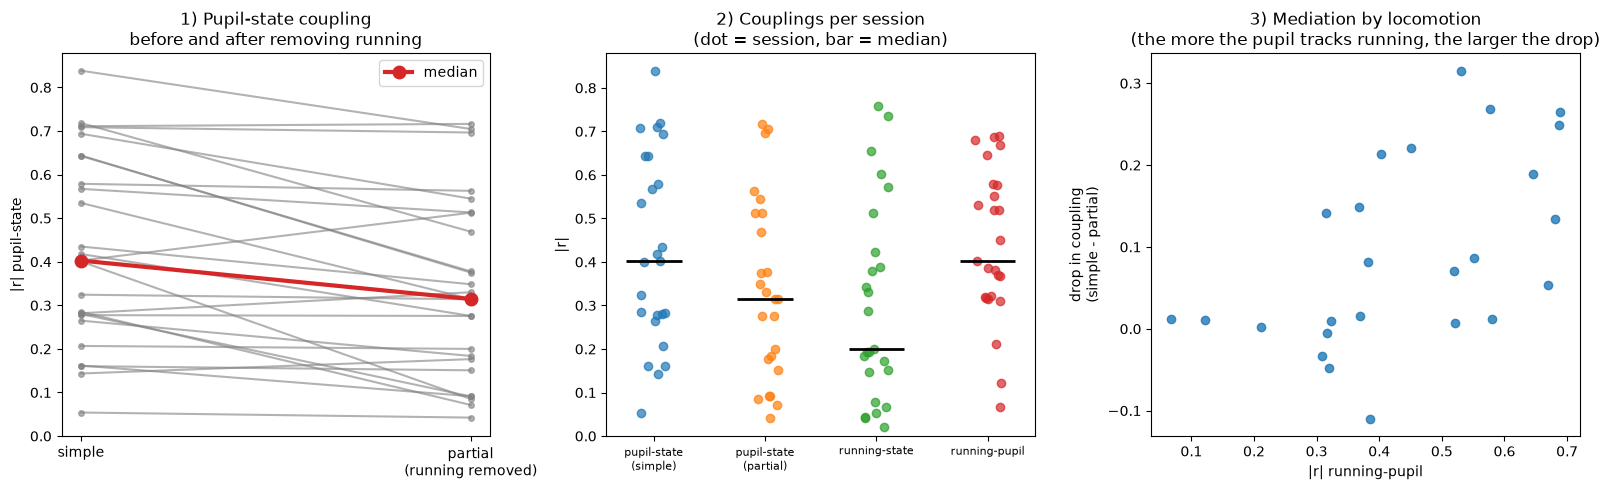

In [11]:
if n >= 2:
    rng_j = np.random.default_rng(0)
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # (1) simple vs partial, one line per session
    ax = axes[0]
    for rs, rp in zip(r_simple, r_partial):
        ax.plot([0, 1], [rs, rp], "-o", color="gray", alpha=0.6, ms=4)
    ax.plot([0, 1], [np.median(r_simple), np.median(r_partial)], "-o", color="tab:red", lw=3,
            ms=9, label="median")
    ax.set_xticks([0, 1]); ax.set_xticklabels(["simple", "partial\n(running removed)"])
    ax.set_ylabel("|r| pupil-state"); ax.set_ylim(bottom=0)
    ax.set_title("1) Pupil-state coupling\nbefore and after removing running"); ax.legend()

    # (2) distribution of |r| across the four couplings
    ax = axes[1]
    cats = [("pupil-state\n(simple)", validas["r_simple"]),
            ("pupil-state\n(partial)", validas["r_partial"]),
            ("running-state", validas["r_run_pc1"]),
            ("running-pupil", validas["r_run_pupil"])]
    for i, (lab, vals) in enumerate(cats):
        x = i + rng_j.uniform(-0.12, 0.12, len(vals))
        ax.scatter(x, vals, alpha=0.7)
        ax.hlines(np.median(vals), i - 0.25, i + 0.25, color="black", lw=2)
    ax.set_xticks(range(len(cats))); ax.set_xticklabels([c[0] for c in cats], fontsize=8)
    ax.set_ylabel("|r|"); ax.set_ylim(bottom=0)
    ax.set_title("2) Couplings per session\n(dot = session, bar = median)")

    # (3) mediation: drop in coupling vs how strongly the pupil tracks running speed
    ax = axes[2]
    caida = validas["r_simple"] - validas["r_partial"]
    ax.scatter(validas["r_run_pupil"], caida, alpha=0.8)
    ax.set_xlabel("|r| running-pupil")
    ax.set_ylabel("drop in coupling\n(simple - partial)")
    ax.set_title("3) Mediation by locomotion\n(the more the pupil tracks running, the larger the drop)")
    plt.tight_layout(); plt.show()

### 5.2 Group decoding

The same comparison with a predictive, out-of-sample model: reconstructing the state from the pupil (GLM and GRU), from running speed (GLM), and from the pupil with running speed removed (GLM). If running decoded better than the pupil and the pupil lost its predictive power once running was removed, the apparent pupil-state link would be locomotion.

In [12]:
dec = validas.dropna(subset=["dec_r_glm"]) if "dec_r_glm" in validas.columns else pd.DataFrame()
nd = len(dec)
if nd >= 2:
    med = lambda c: dec[c].median() if c in dec.columns else float("nan")
    print(f"N sessions with decoding = {nd}\n")
    print("Median r (prediction vs target, peak over tau):")
    print(f"  pupil   -> state  GLM: {med('dec_r_glm'):.3f}   GRU: {med('dec_r_gru'):.3f}")
    print(f"  running -> state  GLM: {med('dec_r_run_glm'):.3f}")
    print(f"  pupil   -> state  GLM (partial, running removed): {med('dec_r_glm_partial'):.3f}\n")

    if {"dec_r_run_glm", "dec_r_glm"} <= set(dec.columns):
        d = dec.dropna(subset=["dec_r_run_glm", "dec_r_glm"])
        try:
            _, p = wilcoxon(d["dec_r_run_glm"], d["dec_r_glm"], alternative="greater")
            print(f"Running decodes BETTER than pupil (Wilcoxon, H1: running>pupil): p={p:.4f}")
        except ValueError:
            print("Running vs pupil: Wilcoxon not applicable.")
    if {"dec_r_glm_partial", "dec_r_glm"} <= set(dec.columns):
        d = dec.dropna(subset=["dec_r_glm_partial", "dec_r_glm"])
        try:
            _, p = wilcoxon(d["dec_r_glm"], d["dec_r_glm_partial"], alternative="greater")
            print(f"Pupil decodes WORSE with running removed (Wilcoxon, H1: simple>partial): p={p:.4f}")
        except ValueError:
            print("Simple vs partial: Wilcoxon not applicable.")
else:
    print("Not enough decoding results; enable RUN_DECODING and re-run section 4.")

N sessions with decoding = 25

Median r (prediction vs target, peak over tau):
  pupil   -> state  GLM: 0.282   GRU: 0.273
  running -> state  GLM: 0.203
  pupil   -> state  GLM (partial, running removed): 0.238

Running decodes BETTER than pupil (Wilcoxon, H1: running>pupil): p=0.9742
Pupil decodes WORSE with running removed (Wilcoxon, H1: simple>partial): p=0.1205


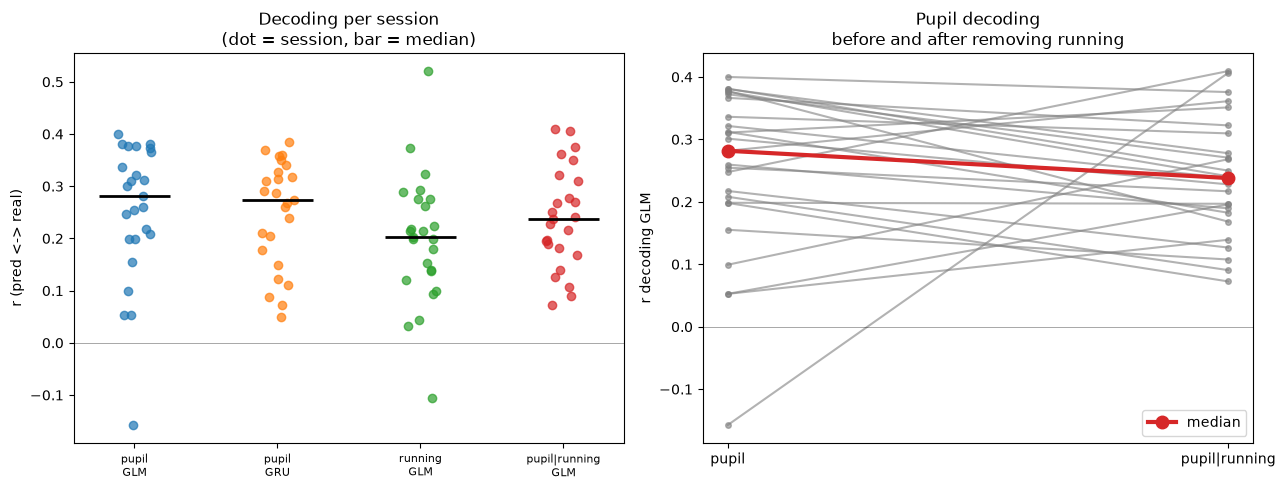

In [13]:
if nd >= 2:
    rj = np.random.default_rng(1)
    fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5))

    cats = [("pupil\nGLM", "dec_r_glm"), ("pupil\nGRU", "dec_r_gru"),
            ("running\nGLM", "dec_r_run_glm"), ("pupil|running\nGLM", "dec_r_glm_partial")]
    for i, (lab, col) in enumerate(cats):
        if col in dec.columns:
            v = dec[col].dropna().values
            a.scatter(i + rj.uniform(-0.12, 0.12, len(v)), v, alpha=0.7)
            if len(v): a.hlines(np.median(v), i - 0.25, i + 0.25, color="black", lw=2)
    a.set_xticks(range(len(cats))); a.set_xticklabels([c[0] for c in cats], fontsize=8)
    a.axhline(0, color="black", lw=0.6, alpha=0.4); a.set_ylabel("r (pred <-> real)")
    a.set_title("Decoding per session\n(dot = session, bar = median)")

    if {"dec_r_glm", "dec_r_glm_partial"} <= set(dec.columns):
        for rs, rp in zip(dec["dec_r_glm"], dec["dec_r_glm_partial"]):
            b.plot([0, 1], [rs, rp], "-o", color="gray", alpha=0.6, ms=4)
        b.plot([0, 1], [dec["dec_r_glm"].median(), dec["dec_r_glm_partial"].median()],
               "-o", color="tab:red", lw=3, ms=9, label="median")
        b.set_xticks([0, 1]); b.set_xticklabels(["pupil", "pupil|running"])
        b.set_ylabel("r decoding GLM"); b.axhline(0, color="black", lw=0.6, alpha=0.4)
        b.set_title("Pupil decoding\nbefore and after removing running"); b.legend()
    plt.tight_layout(); plt.show()

---
## 6. Interpretation

**The pupil-state coupling is robust and only partly explained by running.** Across 25 sessions the median coupling is |r| = 0.403, significant in 14 of them. Regressing out running speed lowers it to 0.315, a systematic drop (Wilcoxon, p = 1.4e-4) but a modest one: in shared variance, about 39 % of the association is attributable to locomotion and about 61 % survives.

**The partial coupling is significant in 14 of 25 sessions**, against roughly one expected by chance (binomial, p < 1e-11). The pupil therefore carries information about the state that is independent of contemporaneous running in most animals.

**Running matters too, but less than expected from the single session.** Running-state coupling is significant in 15 of 25 sessions, with a median |r| of 0.200, well below the pupil's 0.403.

**The decoder agrees.** The pupil reconstructs the state with a median r of 0.282 (GRU 0.273) against 0.203 from running speed, and the test that running decodes better is rejected (p = 0.97). Removing running leaves the pupil at 0.238, a drop that is not significant (p = 0.12). GLM and GRU perform almost identically, consistent with a slow, essentially linear arousal signal.

**The single session analysed first was an outlier.** Its running-state coupling, |r| = 0.758, is the highest in the dataset (which ranges from 0.02 to 0.76), and its partial coupling, 0.071, among the lowest. The conclusion drawn there was correct for that session but does not generalise: at group level pupil and running speed are partially overlapping indices, and the pupil retains a signal of its own.

**Answer.** Across this population the pupil is a partial but genuine index of the population state of VISp, above locomotion. Running speed contributes and should be controlled for, but it does not explain the pupil-state relationship.

### Limitations

- The running control is linear and contemporaneous, so "beyond running" means beyond contemporaneous linear running. Delayed or non-linear effects of locomotion may remain; regressing out lagged running speed would tighten this.
- Per-session couplings are modest (~0.3) and in 4 of 25 sessions the partial coupling slightly exceeds the simple one, which is within noise. The strength of the result is the consistency across sessions, not the size of any single effect.
- PC1 explains a median 12 % of the variance (range 7-27 %), so it is a partial summary of the state. Other definitions of the neural signal were not swept at group level.
- Sessions are heterogeneous in unit count (35-107), eye-tracking quality and running-signal quality, which contains artefactual peaks in some sessions. Spearman correlation limits their influence on the couplings but not on the decoder.
- One dataset, one recording modality and one regime: this does not generalise to other areas, species or behavioural states.

---
## 7. References

- Siegle, J. H., et al. (2021). *Survey of spiking in the mouse visual system reveals functional hierarchy.* **Nature** 592, 86-92. (Allen Visual Coding – Neuropixels; DANDI:000021.)
- de Vries, S. E. J., et al. (2020). *A large-scale standardized physiological survey reveals functional organization of the mouse visual cortex.* **Nature Neuroscience** 23, 138-151.
- Niell, C. M., & Stryker, M. P. (2010). *Modulation of visual responses by behavioral state in mouse visual cortex.* **Neuron** 65, 472-479.
- McGinley, M. J., et al. (2015). *Waking state: rapid variations modulate neural and behavioral responses.* **Neuron** 87, 1143-1161.
- Vinck, M., et al. (2015). *Arousal and locomotion make distinct contributions to cortical activity patterns and visual encoding.* **Neuron** 86, 740-754.
- Stringer, C., et al. (2019). *Spontaneous behaviors drive multidimensional, brainwide activity.* **Science** 364, 255.
- Musall, S., et al. (2019). *Single-trial neural dynamics are dominated by richly varied movements.* **Nature Neuroscience** 22, 1677-1686.
- Viejo, G., et al. (2023). *pynapple, a toolbox for data analysis in neuroscience.* **eLife** 12, e85786.
- OpenScope Databook, Allen Institute. https://alleninstitute.github.io/openscope_databook/